# OpenSqray Tutorial

这个 notebook 演示 OpenSqray 的公开安全 SDPC 工作流。它会在 `/tmp/opensqray_tutorial/` 生成一个 synthetic SDPC-like fixture，并真实执行 parser、`SDPCSlide` facade、Pillow 解码和 CLI。

注意：synthetic fixture 只用于演示 API 形态，不代表 Sqray SDPC 完整官方格式。真实 SDPC 像素读取仍应优先使用配置好的 SDK 后端。

## 1. 环境与导入

在源码仓库中运行时，下面的代码会把 `src/` 加入 `sys.path`。如果你已经通过 `pip install -e .` 安装，也可以直接导入 `opensqray`。

In [1]:
from pathlib import Path
import io
import json
import os
import struct
import subprocess
import sys

from IPython.display import display
from PIL import Image, ImageDraw

REPO_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(REPO_ROOT / "src"))

from opensqray import SDPCSlide
from opensqray.sdpc import read_sdpc

print("repo: current checkout")
print(f"python: {sys.version.split()[0]}")

repo: current checkout
python: 3.13.12


## 2. 生成 synthetic SDPC-like fixture

这里生成的是一个可公开提交的合成二进制 fixture：头部字段模拟 SDPC metadata 区，其中嵌入两个 associated JPEG 候选和四个 tile-sized JPEG。JPEG 图像由 Pillow 动态生成，因此可以在 notebook 中直接显示。

In [2]:
def make_demo_jpeg(width: int, height: int, label: str, bg: tuple[int, int, int]) -> bytes:
    image = Image.new("RGB", (width, height), bg)
    draw = ImageDraw.Draw(image)
    draw.rectangle((12, 12, width - 13, height - 13), outline=(255, 255, 255), width=4)
    draw.text((24, 24), label, fill=(20, 32, 50))
    draw.line((0, height // 2, width, height // 2), fill=(255, 255, 255), width=2)
    draw.line((width // 2, 0, width // 2, height), fill=(255, 255, 255), width=2)
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG", quality=90)
    return buffer.getvalue()


def put_blob(data: bytearray, offset: int, blob: bytes) -> None:
    end = offset + len(blob)
    if end > len(data):
        data.extend(b"\x00" * (end - len(data)))
    data[offset:end] = blob


def make_demo_sdpc(path: Path) -> dict[str, object]:
    data = bytearray(9000)
    metadata_offset = 0x1B34
    data[:12] = b"SQ1.1.9.0430"
    struct.pack_into("<I", data, 0x12, 156)
    struct.pack_into("<I", data, 0x26, 3)
    struct.pack_into("<I", data, 0x2A, 1024)
    struct.pack_into("<I", data, 0x2E, 512)
    struct.pack_into("<I", data, 0x32, 256)
    struct.pack_into("<I", data, 0x36, 256)
    struct.pack_into("<I", data, 0x3A, 320)
    struct.pack_into("<I", data, 0x3E, 180)
    struct.pack_into("<f", data, 0x48, 0.25)
    struct.pack_into("<d", data, 0x4C, 0.104538690)
    struct.pack_into("<I", data, 0x54, 40)
    struct.pack_into("<I", data, 0x58, metadata_offset)

    metadata = (
        b"EI\x00\x03\x00\x00\x00\x00"
        b"OpenSqray-Demo-Camera\x00"
        b"2026/6/14 10:00:00\x00"
        b"OpenSqraySyntheticScanner\x00"
        b"DemoObjective20X\x00"
    )
    put_blob(data, metadata_offset, metadata)

    records: list[dict[str, object]] = []
    cursor = 9000
    embedded = [
        ("label_candidate", make_demo_jpeg(320, 180, "label candidate", (248, 190, 205))),
        ("macro_candidate", make_demo_jpeg(640, 220, "macro candidate", (170, 220, 210))),
        ("tile_0_0", make_demo_jpeg(256, 256, "tile 0,0", (238, 160, 185))),
        ("tile_1_0", make_demo_jpeg(256, 256, "tile 1,0", (210, 185, 225))),
        ("tile_2_0", make_demo_jpeg(256, 256, "tile 2,0", (175, 210, 220))),
        ("tile_3_0", make_demo_jpeg(256, 256, "tile 3,0", (190, 220, 170))),
    ]
    for name, blob in embedded:
        put_blob(data, cursor, blob)
        records.append({"name": name, "offset": cursor, "length": len(blob)})
        cursor += len(blob) + 128

    struct.pack_into("<I", data, 0x16, len(data))
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(data)
    return {"path": str(path), "file_size": len(data), "embedded_records": records}

WORKDIR = Path("/tmp/opensqray_tutorial")
slide_path = WORKDIR / "synthetic_demo.sdpc"
fixture = make_demo_sdpc(slide_path)
print(json.dumps({"path": fixture["path"], "file_size": fixture["file_size"]}, indent=2))

{
  "path": "/tmp/opensqray_tutorial/synthetic_demo.sdpc",
  "file_size": 46029
}


## 3. 解析 SDPC metadata

`read_sdpc()` 返回结构化 metadata。这里限制 JPEG preview 数量，让输出保持短小，适合作为教程展示。

In [3]:
info = read_sdpc(slide_path, scan_jpegs=False, jpeg_preview_limit=12)
summary = {
    "format": "sdpc",
    "schema_version": info.to_dict()["schema_version"],
    "version": info.version,
    "dimensions": {"width": info.dimensions[0], "height": info.dimensions[1]},
    "level_count": info.level_count,
    "tile_size": {"width": info.tile_size[0], "height": info.tile_size[1]},
    "associated_count": info.associated_images["count"],
    "tile_index_status": info.tile_index["status"],
}
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "format": "sdpc",
  "schema_version": "opensqray.sdpc.metadata.v1",
  "version": "SQ1.1.9.0430",
  "dimensions": {
    "width": 1024,
    "height": 512
  },
  "level_count": 3,
  "tile_size": {
    "width": 256,
    "height": 256
  },
  "associated_count": 2,
  "tile_index_status": "candidate"
}


## 4. Associated image 候选

OpenSqray 会把第一个 tile-sized JPEG 之前的非 tile JPEG 记录标记为 associated image 候选。候选名称是启发式角色名，不等同于已确认的 SDPC 官方目录项。

In [4]:
associated = [
    {
        "name": record["name"],
        "size": (record["dimensions"]["width"], record["dimensions"]["height"]),
        "byte_length": record["length"],
    }
    for record in info.associated_images["records"]
]
associated

[{'name': 'thumbnail', 'size': (320, 180), 'byte_length': 5568},
 {'name': 'associated_candidate', 'size': (640, 220), 'byte_length': 9318}]

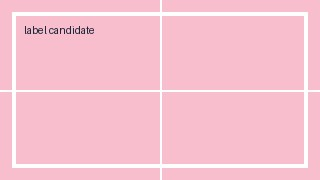

{'associated_name': 'thumbnail', 'mode': 'RGB', 'size': (320, 180)}

In [5]:
associated_name = info.associated_images["records"][0]["name"]
with SDPCSlide(slide_path, jpeg_preview_limit=12) as slide:
    associated_image = slide.read_associated_image(associated_name)

display(associated_image)
{"associated_name": associated_name, "mode": associated_image.mode, "size": associated_image.size}

## 5. Tile candidate 与 `SDPCSlide`

Native 后端当前返回的是 preview 中的候选 tile JPEG bytes。它适合研究和预览，不等同于完整 native `read_region()`。

In [6]:
tiles_preview = info.tile_index["tiles_preview"]
tile_summary = {
    "status": info.tile_index["status"],
    "preview_count": len(tiles_preview),
    "first_tiles": [
        {
            "level": tile["level"],
            "tile_x": tile["tile_x"],
            "tile_y": tile["tile_y"],
            "byte_length": tile["length"],
            "confidence": tile["confidence"],
        }
        for tile in tiles_preview[:4]
    ],
}
print(json.dumps(tile_summary, indent=2, ensure_ascii=False))

{
  "status": "candidate",
  "preview_count": 4,
  "first_tiles": [
    {
      "level": 0,
      "tile_x": 0,
      "tile_y": 0,
      "byte_length": 5391,
      "confidence": "heuristic"
    },
    {
      "level": 0,
      "tile_x": 1,
      "tile_y": 0,
      "byte_length": 5286,
      "confidence": "heuristic"
    },
    {
      "level": 0,
      "tile_x": 2,
      "tile_y": 0,
      "byte_length": 5322,
      "confidence": "heuristic"
    },
    {
      "level": 0,
      "tile_x": 3,
      "tile_y": 0,
      "byte_length": 5504,
      "confidence": "heuristic"
    }
  ]
}


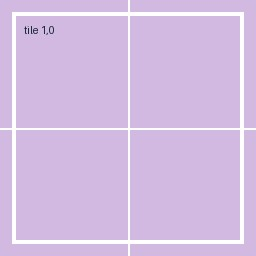

{'tile_jpeg_bytes': 5286, 'tile_image_size': (256, 256)}

In [7]:
with SDPCSlide(slide_path, jpeg_preview_limit=12) as slide:
    tile_jpeg = slide.read_tile_jpeg_bytes(level=0, tile_x=1, tile_y=0)
    tile_image = slide.read_tile_image(level=0, tile_x=1, tile_y=0)

display(tile_image)
{"tile_jpeg_bytes": len(tile_jpeg), "tile_image_size": tile_image.size}

## 6. CLI 示例

下面用同一个 synthetic fixture 运行 CLI。这里设置 `PYTHONPATH=src`，所以即使还没有 `pip install -e .`，源码仓库内也能直接执行。

In [8]:
env = {**os.environ, "PYTHONPATH": str(REPO_ROOT / "src")}
cmd = [sys.executable, "-m", "opensqray.cli", "inspect", str(slide_path), "--compact"]
result = subprocess.run(cmd, cwd=REPO_ROOT, env=env, text=True, capture_output=True, check=False)
print("$", " ".join(["python" if item == sys.executable else item for item in cmd]))
print("exit_code:", result.returncode)
print(result.stdout[:900])

$ python -m opensqray.cli inspect /tmp/opensqray_tutorial/synthetic_demo.sdpc --compact
exit_code: 0
{"associated_images": {"confidence": "heuristic", "count": 2, "limitations": ["Candidate role names are not formal SDPC directory entries yet.", "Only embedded JPEG streams with parseable dimensions are considered."], "records": [{"confidence": "heuristic", "content_type": "image/jpeg", "dimensions": {"height": 180, "width": 320}, "length": 5568, "name": "thumbnail", "offset": 9000, "reason": "leading non-tile JPEG stream before the first tile-sized JPEG record", "record_index": 0}, {"confidence": "heuristic", "content_type": "image/jpeg", "dimensions": {"height": 220, "width": 640}, "length": 9318, "name": "associated_candidate", "offset": 14696, "reason": "leading non-tile JPEG stream before the first tile-sized JPEG record", "record_index": 1}], "strategy": "leading_non_tile_jpegs_before_first_tile_sized_record"}, "dimensions": {"height": 512, "width": 1024}, "experimental": {"pixel_

In [9]:
tile_output = WORKDIR / "tile-1-0.jpg"
cmd = [
    sys.executable, "-m", "opensqray.cli", "read-tile", str(slide_path),
    "--backend", "native",
    "--preview-limit", "12",
    "--level", "0",
    "--tile-x", "1",
    "--tile-y", "0",
    "--output", str(tile_output),
    "--overwrite",
    "--compact",
]
result = subprocess.run(cmd, cwd=REPO_ROOT, env=env, text=True, capture_output=True, check=False)
print("$", " ".join(["python" if item == sys.executable else item for item in cmd]))
print("exit_code:", result.returncode)
print(result.stdout)
print({"output_exists": tile_output.exists(), "output_bytes": tile_output.stat().st_size})

$ python -m opensqray.cli read-tile /tmp/opensqray_tutorial/synthetic_demo.sdpc --backend native --preview-limit 12 --level 0 --tile-x 1 --tile-y 0 --output /tmp/opensqray_tutorial/tile-1-0.jpg --overwrite --compact
exit_code: 0
{"backend": "native", "byte_length": 5286, "content_type": "image/jpeg", "format": "sdpc", "level": 0, "output": "/tmp/opensqray_tutorial/tile-1-0.jpg", "path": "/tmp/opensqray_tutorial/synthetic_demo.sdpc", "tile_x": 1, "tile_y": 0}

{'output_exists': True, 'output_bytes': 5286}


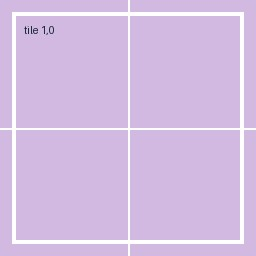

In [10]:
display(Image.open(tile_output))

## 7. SDK 后端说明

公开教程不会依赖专有 SDK runtime。若你的环境配置了 `OPENSQRAY_SDK_LIB_DIR` 或 `OPENSQRAY_SDK_DIR`，可以把上面的 `backend="native"` 改成 `backend="sdk"`，并使用真实 SDPC 文件测试 SDK-backed tile/region 读取。

In [11]:
sdk_env = {
    "OPENSQRAY_SDK_LIB_DIR": bool(os.environ.get("OPENSQRAY_SDK_LIB_DIR")),
    "OPENSQRAY_SDK_DIR": bool(os.environ.get("OPENSQRAY_SDK_DIR")),
    "OPENSQRAY_SDK_EXTRA_LIB_DIRS": bool(os.environ.get("OPENSQRAY_SDK_EXTRA_LIB_DIRS")),
}
sdk_env

{'OPENSQRAY_SDK_LIB_DIR': False,
 'OPENSQRAY_SDK_DIR': False,
 'OPENSQRAY_SDK_EXTRA_LIB_DIRS': False}